In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

In [2]:
SF_20 = np.load('../Data/SAXS/Structure Factors/Bridge_20_SF.npy')
SF_40 = np.load('../Data/SAXS/Structure Factors/Bridge_40_SF.npy')
SF_80 = np.load('../Data/SAXS/Structure Factors/Bridge_80_SF.npy')

In [3]:
simulation_20 = np.load('../Data/Simulations/Bridge 80 Structure Factor/Sample_44_Best/Density_0.005_U_0_7.46293_r0_2.86209_n_30.0_m_1.0/scattering_data/structure_factor-5.npy')

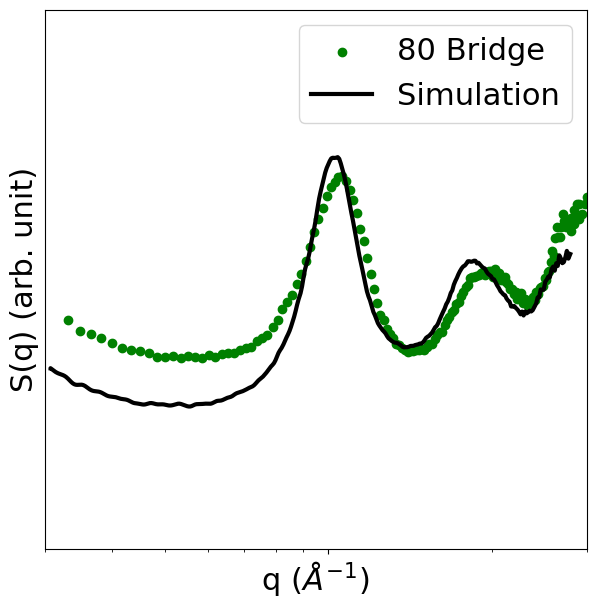

In [9]:
fig, ax = plt.subplots(figsize=(7,7))
#plt.scatter(SF_20[:,0], SF_20[:,1], color = 'C0', label = '20 Bridge')

#plt.scatter(SF_40[:,0], SF_40[:,1], color = 'green', label = '40 Bridge')

plt.scatter(SF_80[:,0], SF_80[:,1], color = 'green', label = '80 Bridge')

plt.plot(simulation_20[:-160,0], simulation_20[:-160,1]-0.1, linewidth = 3, color='k', label = 'Simulation')
plt.xlim([0.003, 0.03])
plt.ylim([-1, 3])

#plt.yscale('log')
plt.ylabel('S(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')

ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)

ax.set_yticks([])

ax.set_xticks([0.01])
ax.set_xticklabels(['0.01'])

plt.xscale('log')

plt.legend()
#plt.savefig('../Figures/Simulation_vs_exp_20.png', dpi=600, bbox_inches="tight")

In [15]:
path = '../Data/Simulations/Bridge 80 Structure Factor/'
filenames = (os.listdir(path))
for i in range(len(filenames)):
    if len(filenames[i]) == 8:
        new_name = filenames[i][0:7] + '0' + filenames[i][-1]
        os.rename(path + filenames[i], path + '/' + new_name)

In [16]:
filenames = sorted(os.listdir(path))

In [18]:
filenames = sorted(os.listdir(path))

score_lst = []
for i in range(len(filenames)):
    filenames2 = sorted(os.listdir(path + filenames[i]))[0]
    filenames3 = sorted(os.listdir(path + filenames[i]))[-2]
    try:
        score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values[0][0]
        score_lst.append(score)
    except:
        print()

frames = len(score_lst)

#Plotting the final image 
for i in range(len(filenames)):
    cmap = cm.coolwarm
    norm = plt.Normalize(np.min(score_lst), np.max(score_lst))
    fig, ax = plt.subplots(figsize=(9,7))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Score')
    plt.plot(SF_80[:,0], SF_80[:,1], color = 'k', label = '80 Bridge (Exp.)', linewidth = 5, marker='o')
    filenames2 = sorted(os.listdir(path + filenames[i]))[0]
    filenames3 = sorted(os.listdir(path + filenames[i]))[-2]
    #plt.title('Iteration ' + str(i))
    try:
        data = np.load(path + filenames[i] + '/' + filenames2 + '/scattering_data/average_structure_factor.npy')
        score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values[0][0]
        plt.plot(data[:,0], data[:,1], linewidth = 3, color=cmap(norm(score)))
        plt.xlim([0.003, 0.03])
        plt.xscale('log')
        #plt.yscale('log')
        plt.ylim([-1, 3])
        plt.ylabel('S(q) (arb. unit)')
        plt.xlabel('q ($\\AA^{-1}$)')
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
        ax.set_yticks([])
        plt.legend()
        plt.savefig('../Figures/Bridge_80_SF_Animation/simulation_'+ str(i) + '.png', dpi=600, bbox_inches="tight")
        
        plt.close()
    except:
        print()
        plt.close()


## Plotting all the figures individually
fig, ax = plt.subplots(figsize=(9,7))
cmap = cm.coolwarm
norm = plt.Normalize(np.min(score_lst), np.max(score_lst))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Score')

for i in range(len(filenames)):
    filenames2 = sorted(os.listdir(path + filenames[i]))[0]
    filenames3 = sorted(os.listdir(path + filenames[i]))[-2]
    
    #plt.title('Iteration ' + str(i))
    try:
        data = np.load(path + filenames[i] + '/' + filenames2 + '/scattering_data/average_structure_factor.npy')
        score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values[0][0]
        plt.xlim([0.003, 0.03])
        plt.plot(data[:,0], data[:,1], linewidth = 3, color=cmap(norm(score)))
        plt.xscale('log')
        #plt.yscale('log')
        plt.ylim([-1, 3])
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
        ax.set_yticks([])
        plt.ylabel('S(q) (arb. unit)')
        plt.xlabel('q ($\\AA^{-1}$)')
    except:
        print()
        #plt.close()
plt.plot(SF_80[:,0], SF_80[:,1], color = 'k', label = '80 Bridge (Exp.)', linewidth = 5, marker='o')
plt.legend()
plt.savefig('../Figures/Bridge_80_SF_Animation/simulation_all.png', dpi=600, bbox_inches="tight")
plt.close()

In [19]:
from PIL import Image
import os
path = '../Figures/Bridge_80_SF_Animation/'
filenames = (os.listdir(path))
for i in range(len(filenames)):
    if len(filenames[i]) == 16:
        new_name = filenames[i][0:11] + '0' + filenames[i][-5]
        os.rename(path + filenames[i], path + '/' + new_name + '.png')

# Folder containing the PNG files

# Get all PNG images, sorted by name
image_files = sorted([f for f in os.listdir(path) if f.endswith('.png')])

# Load the images
images = [Image.open(os.path.join(path, f)) for f in image_files]

# Save as animated GIF
images[0].save('../Figures/Bridge_80_SF_Animation.gif',
               save_all=True,
               append_images=images[1:],
               duration=400,  # milliseconds per frame (adjust as needed)
               loop=1)       



In [22]:
path = '../Data/Simulations/Bridge 80 Structure Factor/'
filenames = sorted(os.listdir(path))

for i in range(len(filenames)):
    filenames2 = sorted(os.listdir(path + filenames[i]))[1]
    filenames3 = sorted(os.listdir(path + filenames[i]))[-1]
    filenames4 = sorted(os.listdir(path + filenames[i]))[-2]
    try:
        input_params = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values.reshape(1,-1)
        score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames4).values[0][0]
        if i == 0:
            input_params_all = input_params
        else:
            input_params_all = np.vstack((input_params_all, input_params))
    except:
        print()

In [23]:
def modified_LJ(r, rmin, rmax, U_0, n, m, r0):
    U = U_0/(n - m) * (m*(r0/r)**n - n*(r0/r)**m)
    F = U_0*m*n*((r0/r)**n - (r0/r)**m)/((n-m)*r)
    return U, F

r0 = 2.13
rmin = 0.75*r0
rmax = 5
m = 12
width = 1000
U_0 = 100
n = 16.98
r_vals = np.linspace(rmin, rmax, width)
U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)

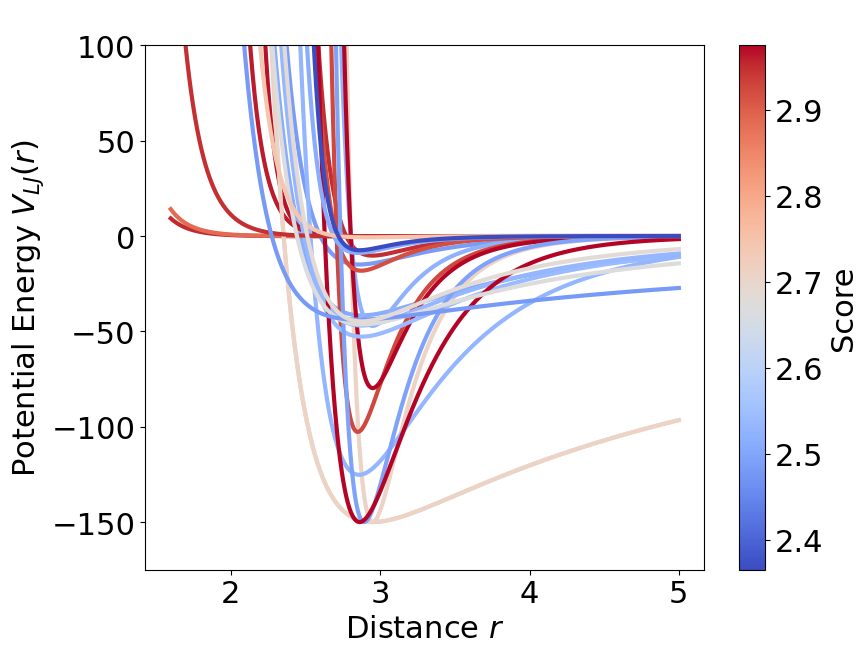

In [24]:
frames = len(score_lst)
cmap = cm.coolwarm
norm = plt.Normalize(np.min(score_lst), np.max(score_lst))


# Plots all the potentials together 
fig, ax = plt.subplots(figsize=(9,7))
for i in range(input_params_all.shape[0]):
    
    params = input_params_all[i, :]
    U_0 = params[1]
    n = params[3]
    r0 = params[2]

    U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)

    plt.plot(r_vals, U, label=f'LJ-nm: n={n}, m={m}, r₀={r0}, U_0={U_0}', linewidth = 3, color=cmap(norm(score_lst[i])))
    plt.xlabel("r")
    plt.ylabel("Potential Energy $V_{LJ}(r)$")
    plt.xlabel('Distance $r$')
    plt.ylim([-175, 100])
    plt.tight_layout()
    #plt.title('Iteration ' + str(i))
    plt.title(' ')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Score')
plt.savefig("../Figures/Potential_80_SF_Animation/potential_plot_all.png", dpi=600, bbox_inches="tight")   





# Plots the potentials individually 

for i in range(input_params_all.shape[0]):
    fig, ax = plt.subplots(figsize=(9,7))
    params = input_params_all[i, :]
    U_0 = params[1]
    n = params[3]
    r0 = params[2]

    U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)

    plt.plot(r_vals, U, label=f'LJ-nm: n={n}, m={m}, r₀={r0}, U_0={U_0}', linewidth = 3, color=cmap(norm(score_lst[i])))
    plt.xlabel("r")
    plt.ylabel("Potential Energy $V_{LJ}(r)$")
    plt.xlabel('Distance $r$')
    plt.ylim([-175, 100])
    plt.tight_layout()
    #plt.title('Iteration ' + str(i))
    plt.title(' ')
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Score')
    plt.savefig('../Figures/Potential_80_SF_Animation/potential_plot_' + str(i) + '.png', dpi=600, bbox_inches="tight")   
    plt.close()



In [25]:
from PIL import Image
import os

path = '../Figures/Potential_80_SF_Animation/'
filenames = (os.listdir(path))
for i in range(len(filenames)):
    if len(filenames[i]) == 20:
        new_name = filenames[i][0:15] + '0' + filenames[i][-5]
        os.rename(path + filenames[i], path + '/' + new_name + '.png')

# Folder containing the PNG files

# Get all PNG images, sorted by name
image_files = sorted([f for f in os.listdir(path) if f.endswith('.png')])

# Load the images
images = [Image.open(os.path.join(path, f)) for f in image_files]

# Save as animated GIF
images[0].save('../Figures/potential_80_SF_animation.gif',
               save_all=True,
               append_images=images[1:],
               duration=400,  # milliseconds per frame (adjust as needed)
               loop=1)       



## plotting last sample

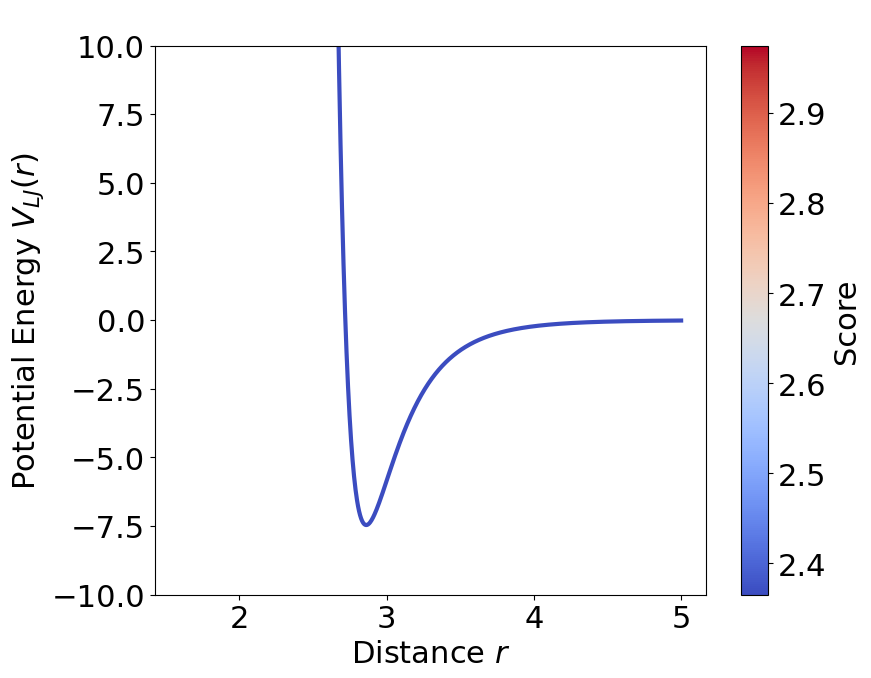

In [26]:
i = -1
fig, ax = plt.subplots(figsize=(9,7))
params = input_params_all[i, :]
U_0 = params[1]
n = params[3]
r0 = params[2]

U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)

plt.plot(r_vals, U, label=f'LJ-nm: n={n}, m={m}, r₀={r0}, U_0={U_0}', linewidth = 3, color=cmap(norm(score_lst[i])))
plt.xlabel("r")
plt.ylabel("Potential Energy $V_{LJ}(r)$")
plt.xlabel('Distance $r$')
plt.ylim([-10, 10])
plt.tight_layout()
#plt.title('Iteration ' + str(i))
plt.title(' ')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Score')
#plt.savefig('../Figures/potential_plot_40_SF_best.png', dpi=600, bbox_inches="tight")   
#plt.close()

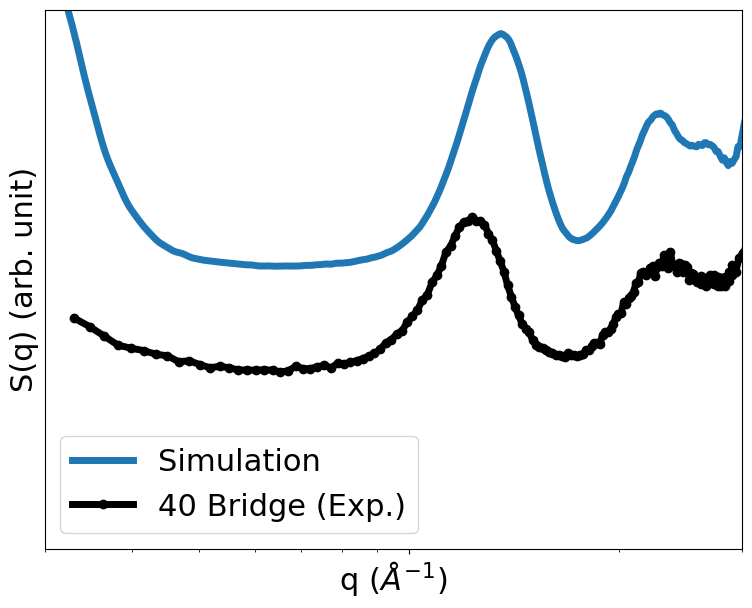

In [ ]:
path = '../Data/Simulations/Bridge 40 Structure Factor/'
filenames = sorted(os.listdir(path))

score_lst = []
for i in range(len(filenames)):
    filenames2 = sorted(os.listdir(path + filenames[i]))[0]
    filenames3 = sorted(os.listdir(path + filenames[i]))[-2]
    try:
        score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values[0][0]
        score_lst.append(score)
    except:
        print()

frames = len(score_lst)


## Plotting all the figures individually
fig, ax = plt.subplots(figsize=(9,7))
i = 0
filenames2 = sorted(os.listdir(path + filenames[i]))[0]
filenames3 = sorted(os.listdir(path + filenames[i]))[-2]

#plt.title('Iteration ' + str(i))
try:
    data = np.load(path + filenames[i] + '/' + filenames2 + '/scattering_data/average_structure_factor.npy')
    score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values[0][0]
    plt.xlim([0.003, 0.03])
    plt.plot(data[:,0], data[:,1]+1, linewidth = 5, color='C0', label='Simulation')
    plt.xscale('log')
    #plt.yscale('log')
    plt.ylim([-1, 3])
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
    ax.set_yticks([])
    plt.ylabel('S(q) (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
except:
    print()
    #plt.close()
plt.plot(SF_40[:,0], SF_40[:,1], color = 'k', label = '40 Bridge (Exp.)', linewidth = 5, marker='o')
plt.legend()
#plt.savefig('../Figures/sf40one_plot.png', dpi=600, bbox_inches="tight")
#plt.close()